# Proyek Predictive Analytics: [Predictive Maintenance]
- **Nama:** [Fiqih Hidayaturrahman]
- **Email:** [fiqihhidayaturrahman@gmail.com]
- **ID Dicoding:** [fiqih hidayaturrahman]

# A. Penjelasan Dataset - NASA Turbofan Engine Degradation Simulation (C-MAPSS)

Dataset ini merupakan data C-MAPSS. C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) adalah simulator yang dikembangkan oleh NASA untuk membuat data sensor dari mesin turbofan (seperti mesin jet di pesawat) yang beroperasi sampai mengalami kerusakan (run-to-failure). Dataset ini dirancang untuk Mensimulasikan bagaimana mesin mengalami degradasi seiring waktu dan bagaimana kerusakan bisa diprediksi dari data sensor.



- Setiap baris data = 1 siklus operasional mesin (satu kali terbang).
- Setiap kolom = informasi tentang kondisi mesin saat siklus tersebut.

**Nama dan Keterangan Kolom-Kolom**
- kolom 1 **unit_number**: Nomor Mesin / Identitas Mesin
- kolom 2 **time_in_cycles**: Urutan waktu/siklus terbang (1, 2, 3, … hingga rusak)
- kolom 3-5 **operational_setting_1-3**: Kondisi operasional (misalnya tekanan, suhu lingkungan, dll. Namun tidak dijelaskan secara detail oleh NASA)
- kolom 6-26 **sensor_1** s/d **sensor_21**: Data dari berbagai sensor internal mesin (getaran, suhu, tekanan, dll)

# B. Import Package/Library/Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

import semua package dan library yang dibutuhkan

In [4]:
# Membaca data training
col_names = ['unit_number', 'time_in_cycles', 
             'operational_setting_1', 'operational_setting_2', 'operational_setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

df_train = pd.read_csv("NASA_Turbofan_Engine_Degradation_Simulation/CMaps/train_FD001.txt", sep=" ", header=None)
df_train.drop(columns=[26, 27], inplace=True)  # Buang kolom kosong di akhir baris
df_train.columns = col_names

# Lihat 5 baris pertama
print(df_train.head())

   unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational_setting_3  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0                  100.0    518.67    641.82   1589.70   1400.60     14.62   
1                  100.0    518.67    642.15   1591.82   1403.14     14.62   
2                  100.0    518.67    642.35   1587.99   1404.20     14.62   
3                  100.0    518.67    642.35   1582.79   1401.87     14.62   
4                  100.0    518.67    642.37   1582.85   1406.22     14.62   

   ...  sensor_12  sensor_13  sensor_14  sensor_15

Membaca seluruh dataset, memberikan nama pada seluruh variabel/fitur dan menghapus kolom kosong di akhir baris

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            20631 non-null  int64  
 1   time_in_cycles         20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float64
 15  se

Dataset berisi 20630 baris data

In [6]:
print("\nMissing values:\n", df_train.isnull().sum())
print("\nDuplicated rows:", df_train.duplicated().sum())


Missing values:
 unit_number              0
time_in_cycles           0
operational_setting_1    0
operational_setting_2    0
operational_setting_3    0
sensor_1                 0
sensor_2                 0
sensor_3                 0
sensor_4                 0
sensor_5                 0
sensor_6                 0
sensor_7                 0
sensor_8                 0
sensor_9                 0
sensor_10                0
sensor_11                0
sensor_12                0
sensor_13                0
sensor_14                0
sensor_15                0
sensor_16                0
sensor_17                0
sensor_18                0
sensor_19                0
sensor_20                0
sensor_21                0
dtype: int64

Duplicated rows: 0


Tidak Terdapat Missing Value dan Duplicated Rows pada dataset yang digunakan

# C. Exploratory Data Analysis (EDA)

## 1. Jumlah Distribusi Siklus Mesin
Melihat distribusi siklus mesin hidup sebelum rusak:

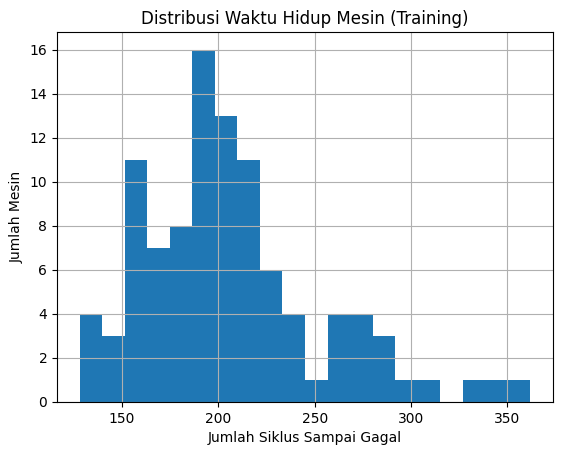

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64

In [7]:
lifespan = df_train.groupby('unit_number')['time_in_cycles'].max()
lifespan.hist(bins=20)
plt.title("Distribusi Waktu Hidup Mesin (Training)")
plt.xlabel("Jumlah Siklus Sampai Gagal")
plt.ylabel("Jumlah Mesin")
plt.show()

lifespan.describe()

Berdasarkan distribusi waktu hidup mesin yang ditampilkan, ada beberapa kesimpulan:
-  **Analisis Distribusi:**
    - Rata-rata Waktu Hidup Mesin (mean): Rata-rata waktu hidup mesin adalah sekitar 206 siklus, dengan rentang nilai antara 128 hingga 362 siklus.
    - Variasi Waktu Hidup Mesin (std): Ada variasi yang cukup besar (sekitar 46 siklus) antara mesin yang memiliki waktu hidup pendek dan panjang.
    - Median (50%): Nilai median dari waktu hidup mesin adalah 199 siklus, yang sedikit lebih rendah dari rata-rata, menunjukkan bahwa sebagian besar mesin memiliki waktu hidup yang relatif lebih pendek daripada rata-rata.
    - Distribusi: Dalam histogram, Anda dapat melihat bahwa sebagian besar mesin cenderung gagal dalam rentang 170-230 siklus, dengan beberapa mesin yang memiliki waktu hidup yang jauh lebih panjang, mendekati nilai maksimum 362 siklus.

## 2. Plot Sensor Terhadap Waktu Siklus
Contoh, melihat bagaimana **sensor_2** pada **unit_id: 10** berubah terhadap waktu siklus untuk satu mesin:

In [2]:
unit_id = 10  # contoh unit
df_unit = df_train[df_train['unit_number'] == unit_id]

plt.plot(df_unit['time_in_cycles'], df_unit['sensor_2'])
plt.title(f"Sensor 2 - Mesin {unit_id}")
plt.xlabel("Siklus")
plt.ylabel("Nilai Sensor 2")
plt.grid(True)
plt.show()

NameError: name 'df_train' is not defined

Grafik menunjukan bahwa semakin banyak siklus waktu pada mesin (mesin digunakan), nilai pada **Sensor 2** unit 10 meningkat.

## 3. Menghitung Remaining Useful Life (RUL)

**Remaining Useful Life (RUL)**, adalah konsep yang digunakan dalam konteks prediktif maintenance (pemeliharaan prediktif). RUL merujuk pada perkiraan waktu atau jumlah siklus operasional yang tersisa sebelum sebuah mesin atau komponen gagal atau mengalami kerusakan yang signifikan. dengan kata lain, **Remaining Useful Life (RUL)** merupakan estimasi tentang berapa lama lagi (Siklus) suatu komponen atau sistem dapat berfungsi dengan baik sebelum diperlukan perbaikan atau penggantian.

Karena Dataset **train_FD001** tidak memiliki label RUL (Remaining Useful Life), maka nilai RUL perlu dihitung.

In [7]:
# Hitung RUL
rul_df = df_train.groupby('unit_number')['time_in_cycles'].max().reset_index()
rul_df.columns = ['unit_number', 'max_cycle']

Menghitung nilai RUL (Remaining Useful Life pada dataset berdasarkan time cycle dan max cycle dari setiap unit)

In [8]:
# Gabungkan ke dataset asli
df_train = df_train.merge(rul_df, on='unit_number')
df_train['RUL'] = df_train['max_cycle'] - df_train['time_in_cycles']

menggabungkan hasil perhitungan RUL dengan dataset asli

In [9]:
print(df_train.head())

   unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational_setting_3  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0                  100.0    518.67    641.82   1589.70   1400.60     14.62   
1                  100.0    518.67    642.15   1591.82   1403.14     14.62   
2                  100.0    518.67    642.35   1587.99   1404.20     14.62   
3                  100.0    518.67    642.35   1582.79   1401.87     14.62   
4                  100.0    518.67    642.37   1582.85   1406.22     14.62   

   ...  sensor_14  sensor_15  sensor_16  sensor_17

Nilai RUL berhasil digabungkan dengan Dataset Asli

In [10]:
# Simpan hasil ke file CSV
df_train.to_csv("train_FD001_with_RUL.csv", index=False)
print("File berhasil disimpan sebagai 'train_FD001_with_RUL.csv'")

File berhasil disimpan sebagai 'train_FD001_with_RUL.csv'


Menyimpan hasil penggabungan nilai RUL dan Dataset asli kedalam bentuk file .csv

## 4. Distibusi RUL
Melihat sebaran umur sisa mesin secara umum.

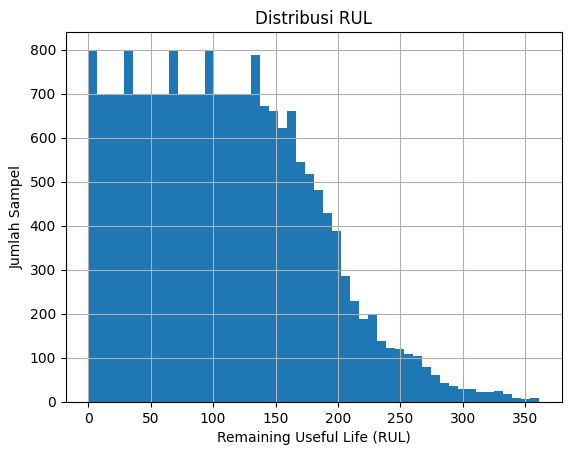

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

In [11]:
df_train['RUL'].hist(bins=50)
plt.title("Distribusi RUL")
plt.xlabel("Remaining Useful Life (RUL)")
plt.ylabel("Jumlah Sampel")
plt.show()

df_train['RUL'].describe()

Berdasarkan distribusi RUL, dapat diambil kesimpulan:
- Sebagian besar data memiliki nilai **RUL** rendah-menengah, dan hanya sedikit data yang memiliki RUL sangat tinggi (dekat 361).
- Banyak data dikumpulkan hingga mesin benar-benar gagal.
- Dengan 25% = 51 dan 75% = 155, sebagian besar nilai **RUL** terletak dalam rentang tersebut. Artinya model lebih baik dilatih dan diuji secara cermat pada rentang ini.

## 5. Korelasi Antar Sensor
Mendeteksi sensor yang redundant atau sangat berkorelasi (digunakan untuk seleksi fitur).

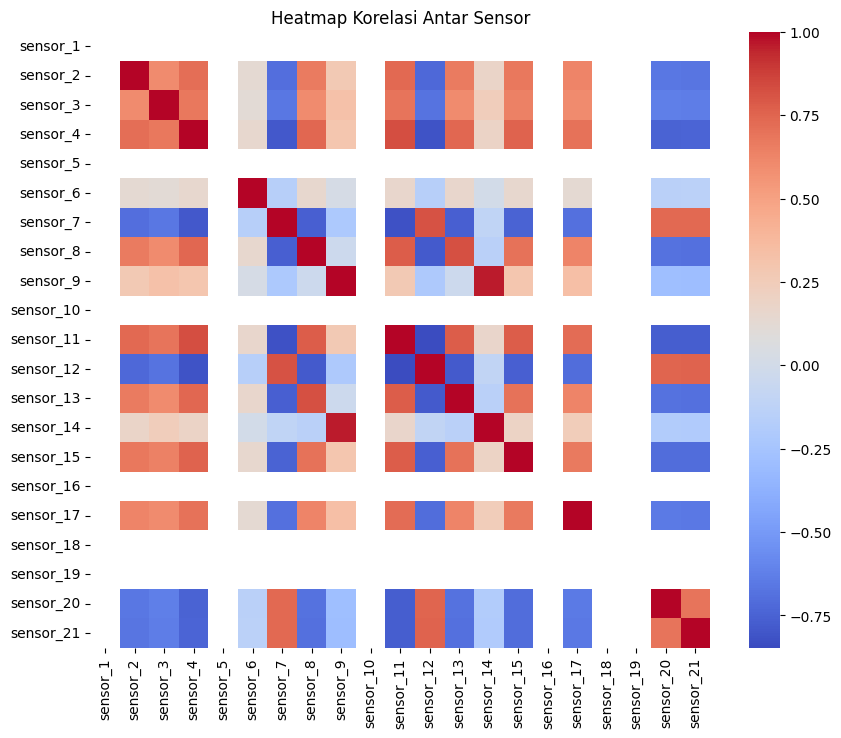

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[[f'sensor_{i}' for i in range(1, 22)]].corr(), annot=False, cmap='coolwarm')
plt.title("Heatmap Korelasi Antar Sensor")
plt.show()

heatmap menunjukan tingkat korelasi positif yang tinggi antara sensor 9 dan 14.

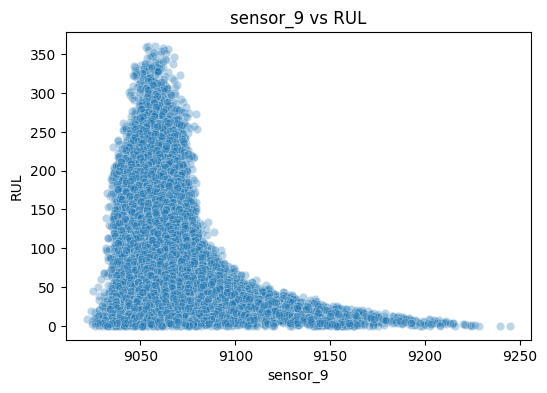

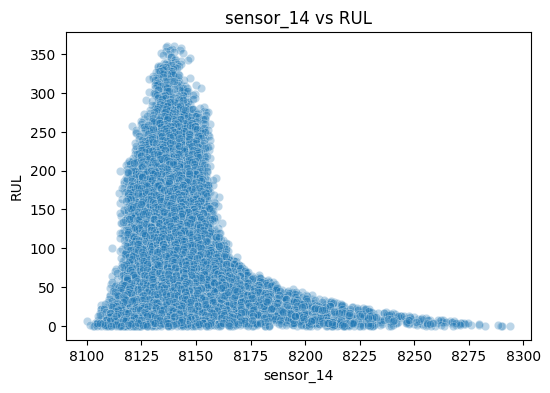

In [13]:
for sensor in ['sensor_9', 'sensor_14']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_train[sensor], y=df_train['RUL'], alpha=0.3)
    plt.title(f'{sensor} vs RUL')
    plt.xlabel(sensor)
    plt.ylabel('RUL')
    plt.show()

Hasil scaterplot menunjukan pola nilai pada sensor 9 dan 14 yang saling berkorelasi. Scatterplot menunjukan persebaran nilai yang sama antara sensor 9 dan 14

## 6. Korelasi Sensor Terhadap RUL

In [14]:
correlations = df_train[[f'sensor_{i}' for i in range(1, 22)] + ['RUL']].corr()['RUL'].drop('RUL')
print(correlations.sort_values(ascending=False))

sensor_12    0.671983
sensor_7     0.657223
sensor_21    0.635662
sensor_20    0.629428
sensor_6    -0.128348
sensor_14   -0.306769
sensor_9    -0.390102
sensor_13   -0.562569
sensor_8    -0.563968
sensor_3    -0.584520
sensor_17   -0.606154
sensor_2    -0.606484
sensor_15   -0.642667
sensor_4    -0.678948
sensor_11   -0.696228
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


- Mayoritas sensor memiliki korelasi yang cukup tinggi dan seimbang dengan **RUL**
- **Sensor 12** memiliki korelasi positive paling tinggi dan **Sensor 11** memiliki korelasi negative paling rendah terhadap **RUL**
- **Sensor 1,5,10,16,18,19** tidak memiliki korelasi sama sekali dengan **RUL**. kita akan melihat nilai distribusi sensor tersebut dibawah ini.

### a. Distibusi nilai sensor yang tidak berkolerasi dengan RUL

In [15]:
df_train[['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']].describe()

,sensor_1,sensor_5,sensor_10,sensor_16,sensor_18,sensor_19
count,20631.00,2.063100e+04,20631.0,2.063100e+04,20631.0,20631.0
mean,518.67,1.462000e+01,1.3,3.000000e-02,2388.0,100.0
std,0.00,1.776400e-15,0.0,1.387812e-17,0.0,0.0
min,518.67,1.462000e+01,1.3,3.000000e-02,2388.0,100.0
25%,518.67,1.462000e+01,1.3,3.000000e-02,2388.0,100.0
50%,518.67,1.462000e+01,1.3,3.000000e-02,2388.0,100.0
75%,518.67,1.462000e+01,1.3,3.000000e-02,2388.0,100.0
max,518.67,1.462000e+01,1.3,3.000000e-02,2388.0,100.0


Bisa dilihat bahwa sensor-sensor seperti **sensor_1, sensor_10, sensor_16, sensor_18, dan sensor_19** memiliki masalah distribusi yang signifikan, yang menyebabkan mereka tidak memiliki korelasi yang jelas dengan **RUL**.

###  b. Korelasi RUL dengan Sensor 11 dan 12

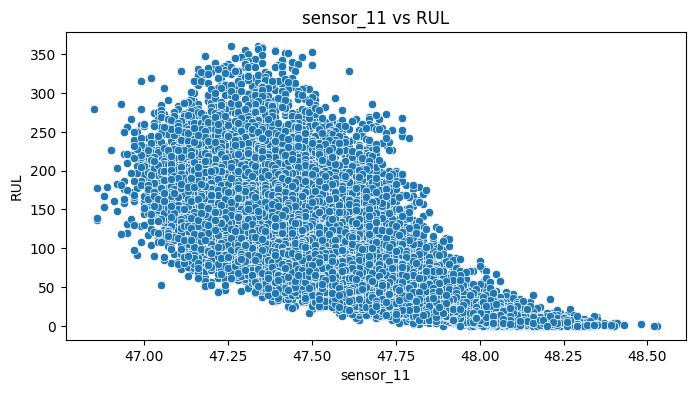

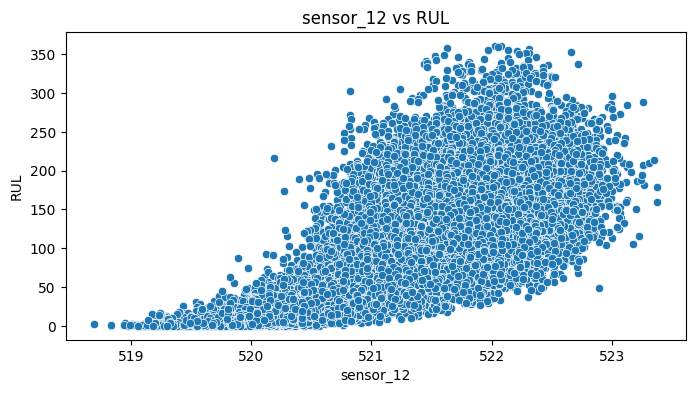

In [16]:
for sensor in ['sensor_11', 'sensor_12']:
    plt.figure(figsize=(8,4))
    sns.scatterplot(x=df_train[sensor], y=df_train['RUL'])
    plt.title(f'{sensor} vs RUL')
    plt.xlabel(sensor)
    plt.ylabel('RUL')
    plt.show()

Pada Scatter Plot dapat dilihat:
- Persebaran Unit dengan **RUL** tinggi memiliki nilai pada **Sensor 11** yang rendah.
- Persebaran Unit dengan **RUL** tinggi memiliki nilai pada **Sensor 11** yang tinggi.

# D. Data Preparation


## 1. Normalisasi MinMaxScaller
Normalisasi pada fitur Sensor

In [17]:
# List of sensor columns
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]  # sensor_1 to sensor_21

# Inisialisasi scaler
scaler = MinMaxScaler()

# Terapkan normalisasi pada kolom sensor saja
df_train[sensor_cols] = scaler.fit_transform(df_train[sensor_cols])

# Cek hasil normalisasi
print(df_train[sensor_cols].head())

   sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  \
0       0.0  0.183735  0.406802  0.309757       0.0       1.0  0.726248   
1       0.0  0.283133  0.453019  0.352633       0.0       1.0  0.628019   
2       0.0  0.343373  0.369523  0.370527       0.0       1.0  0.710145   
3       0.0  0.343373  0.256159  0.331195       0.0       1.0  0.740741   
4       0.0  0.349398  0.257467  0.404625       0.0       1.0  0.668277   

   sensor_8  sensor_9  sensor_10  ...  sensor_12  sensor_13  sensor_14  \
0  0.242424  0.109755        0.0  ...   0.633262   0.205882   0.199608   
1  0.212121  0.100242        0.0  ...   0.765458   0.279412   0.162813   
2  0.272727  0.140043        0.0  ...   0.795309   0.220588   0.171793   
3  0.318182  0.124518        0.0  ...   0.889126   0.294118   0.174889   
4  0.242424  0.149960        0.0  ...   0.746269   0.235294   0.174734   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0   0.363986        0.0

Melakukan normalisasi pada nilai fitur/variabel sensor menjadi rentang 0-1 untuk memastikan bahwa fitur-fitur (dalam hal ini kolom sensor) berada dalam skala yang seragam.

In [19]:
# Inisialisasi scaler untuk target (RUL)
target_scaler = MinMaxScaler()

# Terapkan normalisasi pada RUL
df_train['RUL'] = target_scaler.fit_transform(df_train[['RUL']])

# Cek hasil normalisasi
print(df_train['RUL'].head())

0    0.529086
1    0.526316
2    0.523546
3    0.520776
4    0.518006
Name: RUL, dtype: float64


Melakukan normalisasi pada nilai fitur/variabel RUL menjadi rentang 0-1 untuk memastikan bahwa fitur-fitur (dalam hal ini kolom RUL) berada dalam skala yang seragam.

## 2. Drop Data
Drop data ****'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'** karena tidak berkorelasi dengan **RUL**

In [20]:
df_train.drop(columns=['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19'], inplace=True)

kolom 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19' telah di buang karena tidak berkorelasi dengan RUL berdasarkan hasil exploratory data analysis

In [21]:
print(df_train.head())

   unit_number  time_in_cycles  operational_setting_1  operational_setting_2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational_setting_3  sensor_2  sensor_3  sensor_4  sensor_6  sensor_7  \
0                  100.0  0.183735  0.406802  0.309757       1.0  0.726248   
1                  100.0  0.283133  0.453019  0.352633       1.0  0.628019   
2                  100.0  0.343373  0.369523  0.370527       1.0  0.710145   
3                  100.0  0.343373  0.256159  0.331195       1.0  0.740741   
4                  100.0  0.349398  0.257467  0.404625       1.0  0.668277   

   ...  sensor_11  sensor_12  sensor_13  sensor_14

menampilkan dataset yang telah dibersihkan dari fitur yang tidak berkorelasi

## 3. Menentukan Kolom Fitur dan Label

In [22]:
feature_cols = [col for col in df_train.columns if col.startswith('sensor_') or col.startswith('operational_setting')]
label_col = 'RUL'
window_size = 30

menyiapkan kolom-kolom 'sensor_' dan 'operational_setting' yang akan digunakan sebagai fitur (input) dan 'RUL' sebagai target (output) dalam model prediksi, serta menentukan ukuran jendela waktu '30' yang akan digunakan untuk memproses data. Model akan melihat 30 langkah waktu sebelumnya untuk memprediksi nilai target 'RUL'

## 4. Truncation / Capping RUL
Untuk menghindari outlier, dan fokus ke prediksi saat mesin mendekati gagal

In [23]:
upper_limit = 200
lower_limit = 0
df_train['RUL'] = df_train['RUL'].clip(lower=lower_limit, upper=upper_limit)
df_train['RUL'].describe()

count    20631.000000
mean         0.298637
std          0.190806
min          0.000000
25%          0.141274
50%          0.285319
75%          0.429363
max          1.000000
Name: RUL, dtype: float64

Membatasi (clip) nilai Remaining Useful Life (RUL) dalam rentang tertentu agar nilai target tetap berada dalam batas yang wajar saat digunakan untuk pelatihan model prediksi. Ditentukan bahwa nilai RUL tidak boleh lebih besar dari 200 dan tidak boleh lebih kecil dari 0. Nilai ini diambil berdasarkan nilai distribusi RUL pada rentang 75% hingga 85%

## 5. Buat sequence data untuk LSTM (windowing)
 - Mengambil sub-sekuens dari data untuk setiap unit dan memformatnya menjadi input yang cocok untuk pelatihan model LSTM.
 - Data fitur disusun dalam bentuk (samples, window_size, features), sementara target (RUL) disusun dalam bentuk vektor dengan dimensi (samples,), yang sesuai dengan format input dan target model LSTM.
 - Data Preprocessing untuk Time Series: Mempersiapkan data time series dalam bentuk yang sesuai untuk model yang memerlukan input berbentuk urutan waktu (sekuens).
 - Kode ini mempersiapkan data untuk pelatihan model LSTM, di mana data dibagi menjadi sekuens berukuran window_size dan targetnya adalah RUL pada akhir jendela waktu tersebut.

In [24]:
sequences = []
targets = []

for unit in df_train['unit_number'].unique():
    unit_data = df_train[df_train['unit_number'] == unit]
    for i in range(len(unit_data) - window_size + 1):
        window = unit_data.iloc[i:i + window_size]
        sequence = window[feature_cols].values
        target = window[label_col].values[-1]  # RUL pada akhir window
        sequences.append(sequence)
        targets.append(target)

membangun data input dan target untuk model pembelajaran berbasis deret waktu (time series) dari data df_train. Tujuannya adalah membuat kumpulan sequences (urutan data fitur) dan targets (nilai RUL akhir dari setiap urutan) yang bisa digunakan untuk melatih model seperti LSTM. 'sequences' akan berisi potongan-potongan data input (berbentuk matriks 2D) dari setiap mesin (unit). 'targets' akan berisi label 'RUL' yang menjadi target prediksi, satu untuk setiap sequence.

In [25]:
X = np.array(sequences)
y = np.array(targets)

print("X shape:", X.shape)  # (samples, window_size, features)
print("y shape:", y.shape)  # (samples,)

X shape: (17731, 30, 18)
y shape: (17731,)


mengubah list berisi sequence dan target yang telah dibuat sebelumnya menjadi array NumPy agar bisa digunakan sebagai input dan output untuk model machine learning atau deep learning, seperti LSTM.

## 6. Pemisahan Data (Train-Test Split)
Membagi data 80% untuk pelatihan dan 20% untuk pengujian

In [26]:
test_size = 0.2  # 20% data untuk pengujian

# Membagi data secara time-series, dengan memastikan urutan waktu tetap terjaga
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)

# Menampilkan bentuk data pelatihan dan pengujian
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14184, 30, 18)
X_test shape: (3547, 30, 18)
y_train shape: (14184,)
y_test shape: (3547,)


membagi dataset X dan y ke dalam data pelatihan (train) dan data pengujian (test) sambil menjaga urutan waktu.

# E. Modelling (LSTM)
Untuk membangun model LSTM (Long Short-Term Memory), kita akan menggunakan framework Keras yang ada dalam TensorFlow. LSTM adalah jenis jaringan saraf yang sangat cocok untuk menangani data urutan waktu (time-series), seperti data sensor.

**Langkah-langkah Membangun Model LSTM:**
1. Menyiapkan Model LSTM
    - Menggunakan lapisan LSTM untuk menangani urutan data.
    - Setelah LSTM, tambahkan beberapa lapisan tambahan (misalnya, Dense layer) untuk prediksi.
2. Mengompilasi Model
    - Model LSTM akan dikompilasi menggunakan optimasi dan loss function yang sesuai untuk regresi (karena memprediksi RUL yang bersifat kontinu).
3. Melatih Model
    - Melatih model menggunakan data pelatihan (X_train dan y_train), dan menggunakan data pengujian (X_test dan y_test) untuk validasi.

## 1. Menyiapkan Model LSTM

In [ ]:
# Membangun model LSTM
model = Sequential()

# Lapisan LSTM pertama
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))  # Dropout untuk regularisasi

# Lapisan LSTM kedua
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))  # Dropout untuk regularisasi

# Lapisan Dense untuk output
model.add(Dense(units=1))  # 1 unit karena kita memprediksi nilai kontinu (RUL)

e:\Laskar_AI\Submission\04._Machine_Learning_Terapan\Submission_1\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- Input: data time-series sensor (dalam window) dari setiap unit mesin.
- Arsitektur: 2 lapisan LSTM dengan dropout, lalu dense 1 output.
- Output: prediksi nilai Remaining Useful Life (RUL) dalam bentuk numerik.

## 2. Mengompilasi Model

In [28]:
# Mengompilasi model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Menampilkan ringkasan model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,337 (212.25 KB)

 Trainable params: 54,337 (212.25 KB)

 Non-trainable params: 0 (0.00 B)

mengompilasi model LSTM yang telah dibuat sebelumnya agar siap untuk dilatih, dan menampilkan ringkasan struktur model

In [29]:
# ReduceLROnPlateau: Kurangi learning rate jika validation loss tidak membaik
reduce_lr = ReduceLROnPlateau(monitor='val_loss',  # Memantau loss pada data validasi
                              factor=0.5,         # Mengurangi learning rate menjadi setengahnya
                              patience=5,         # Menunggu 5 epoch jika loss tidak membaik
                              verbose=1,          # Menampilkan informasi saat learning rate dikurangi
                              min_lr=1e-6)        # Batas bawah untuk learning rate

# EarlyStopping: Hentikan pelatihan jika validation loss tidak membaik
early_stop = EarlyStopping(monitor='val_loss',    # Memantau loss pada data validasi
                           patience=10,           # Menunggu 10 epoch jika loss tidak membaik
                           verbose=1,             # Menampilkan informasi saat training berhenti
                           restore_best_weights=True)  # Mengembalikan bobot terbaik

# ModelCheckpoint: Simpan model dengan bobot terbaik berdasarkan validation loss
model_checkpoint = ModelCheckpoint('best_model.h5',   # Nama file untuk menyimpan model
                                   monitor='val_loss', # Memantau validation loss
                                   save_best_only=True, # Simpan hanya model terbaik
                                   verbose=1)           # Menampilkan informasi saat model disimpan

fungsi yang dipanggil selama proses pelatihan untuk memantau, mengatur, dan mengendalikan proses training
1. ReduceLROnPlateau:
    - Menurunkan learning rate secara otomatis jika model mengalami stagnasi dalam validasi.
    - monitor='val_loss': Pantau nilai loss pada data validasi.
    - factor=0.5: Jika tidak ada perbaikan, kurangi learning rate jadi setengah dari nilai sebelumnya.
    - patience=5: Tunggu 5 epoch tanpa perbaikan sebelum mengurangi.
    - min_lr=1e-6: Batasi minimum learning rate agar tidak terlalu kecil.

2. early_stop:
    - Menghentikan pelatihan lebih awal jika model tidak membaik untuk menghindari overfitting dan pemborosan waktu.
    - patience=10: Tunggu maksimal 10 epoch tanpa peningkatan sebelum berhenti.
    - restore_best_weights=True: Kembalikan bobot terbaik model yang diperoleh selama pelatihan (bukan bobot di akhir epoch).

3. model_checkpoint:
    - Menyimpan model ke file setiap kali model mencapai performa validasi terbaik.
    - save_best_only=True: Hanya menyimpan model jika val_loss membaik.



## 3. Melatih Model

In [30]:
# Fit model dengan callbacks
history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=64,
                    validation_data=(X_test, y_test),
                    callbacks=[reduce_lr, early_stop, model_checkpoint])  # Menambahkan callbacks

Epoch 1/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0284
Epoch 1: val_loss improved from inf to 0.02159, saving model to best_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.0284 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 2/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0125
Epoch 2: val_loss improved from 0.02159 to 0.01773, saving model to best_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0125 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 3/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0119
Epoch 3: val_loss did not improve from 0.01773
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0119 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 4/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0109
Epoch 4: val_loss improved from 0.01773 to 0.01359, saving model to best_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0109 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 5/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0100
Epoch 5: val_loss did not improve from 0.01359
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0100 - val_loss: 0.0143 - learning_rate: 0.0010
Epoch 6/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0085
Epoch 6: val_loss did not improve from 0.01359
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0085 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 7/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0088
Epoch 7: val_loss did not improve from 0.01359
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0088 - val_loss: 0.0143 - learning_rate: 0.0010
Epoch 8/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0082
Epoch 8: val_loss improved from 0.01359 to 0.01306, saving model to best_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0082 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 9/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0079
Epoch 9: val_loss did not improve from 0.01306
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0079 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 10/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0078
Epoch 10: val_loss did not improve from 0.01306
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0078 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 11/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0075
Epoch 11: val_loss improved from 0.01306 to 0.01178, saving model to best_model.h5


222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0075 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 12/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0075
Epoch 12: val_loss did not improve from 0.01178
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0075 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 13/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0073
Epoch 13: val_loss did not improve from 0.01178
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0073 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 14/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0073
Epoch 14: val_loss did not improve from 0.01178
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0073 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 15/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0067
Epoch 15: val_loss did not improve from 0.01178
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0067 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 16/200
221/222 ━━━━━━━

222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0065 - val_loss: 0.0117 - learning_rate: 5.0000e-04
Epoch 20/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0066
Epoch 20: val_loss did not improve from 0.01174
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0066 - val_loss: 0.0120 - learning_rate: 5.0000e-04
Epoch 21/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0063
Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: val_loss did not improve from 0.01174
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0063 - val_loss: 0.0140 - learning_rate: 5.0000e-04
Epoch 22/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0062
Epoch 22: val_loss did not improve from 0.01174
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0062 - val_loss: 0.0131 - learning_rate: 2.5000e-04
Epoch 23/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0061
Epoch 23: val_loss did not improve from 0.01174
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26

222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0062 - val_loss: 0.0115 - learning_rate: 2.5000e-04
Epoch 25/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0062
Epoch 25: val_loss did not improve from 0.01149
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0062 - val_loss: 0.0115 - learning_rate: 2.5000e-04
Epoch 26/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0063
Epoch 26: val_loss did not improve from 0.01149
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0063 - val_loss: 0.0125 - learning_rate: 2.5000e-04
Epoch 27/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0063
Epoch 27: val_loss did not improve from 0.01149
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0063 - val_loss: 0.0125 - learning_rate: 2.5000e-04
Epoch 28/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0062
Epoch 28: val_loss did not improve from 0.01149
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0062 - val_loss: 0.0126 - learning_rate: 2.5000e-04
Epoch 29

222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0060 - val_loss: 0.0114 - learning_rate: 2.5000e-04
Epoch 30/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0061
Epoch 30: val_loss did not improve from 0.01145
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0061 - val_loss: 0.0125 - learning_rate: 1.2500e-04
Epoch 31/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0063
Epoch 31: val_loss did not improve from 0.01145
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0063 - val_loss: 0.0129 - learning_rate: 1.2500e-04
Epoch 32/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0059
Epoch 32: val_loss did not improve from 0.01145
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0059 - val_loss: 0.0116 - learning_rate: 1.2500e-04
Epoch 33/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0059
Epoch 33: val_loss did not improve from 0.01145
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0059 - val_loss: 0.0119 - learning_rate: 1.2500e-04
Epoch 3

222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0060 - val_loss: 0.0114 - learning_rate: 1.2500e-04
Epoch 35/200
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0059
Epoch 35: val_loss did not improve from 0.01141
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0059 - val_loss: 0.0119 - learning_rate: 6.2500e-05
Epoch 36/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0057
Epoch 36: val_loss did not improve from 0.01141
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0057 - val_loss: 0.0122 - learning_rate: 6.2500e-05
Epoch 37/200
221/222 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0060
Epoch 37: val_loss did not improve from 0.01141
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0060 - val_loss: 0.0127 - learning_rate: 6.2500e-05
Epoch 38/200
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0060
Epoch 38: val_loss did not improve from 0.01141
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0060 - val_loss: 0.0125 - learning_rate: 6.2500e-05
Epoch 39

Hasil pelatihan model dikembalikan ke epoch 34 dengan hasil terbaik berdasarkan pemantauan early_stop

# F. Evaluasi

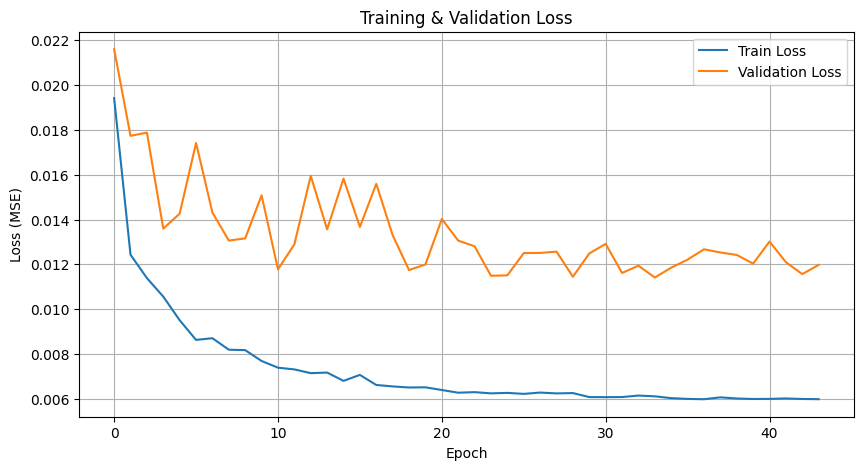

In [32]:
# Visualisasi loss training dan validasi
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Hasil pemantauasn proses pelatihan menunjukan penurunan drastis pasa nilai loss train dan val los menunjukan penurunan yang kurang stabil namun pasti.

In [31]:
# Menyimpan model
model.save('lstm_model_1.h5')

Menyimpan model pelatihan dengan format .h5

In [35]:
# Load model terbaik dari pelatihan
best_model = load_model('best_model.h5')

# Prediksi pada data test
y_pred = best_model.predict(X_test).flatten()
y_true = y_test.flatten()

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


memuat model terbaik yang telah disimpan selama pelatihan, lalu menggunakannya untuk melakukan prediksi pada data pengujian dan menyamakan bentuk hasil prediksi dan label asli agar bisa dianalisis lebih lanjut.

In [36]:
# Hitung metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
rmse = math.sqrt(mean_squared_error(y_true, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 0.07
Root Mean Squared Error (RMSE): 0.11


menghitung dua metrik evaluasi utama untuk regresi Mean Absolute Error (MAE) dan Root Mean Squared Error (RMSE) untuk menilai seberapa baik model memprediksi nilai Remaining Useful Life (RUL) pada data uji.

1. MAE 0.07 berarti rata-rata kesalahan prediksi hanya sekitar 7% dari skala RUL asli.
2. RMSE 0.11 menunjukkan bahwa error lebih besar diberi penalti, tapi tetap rendah.

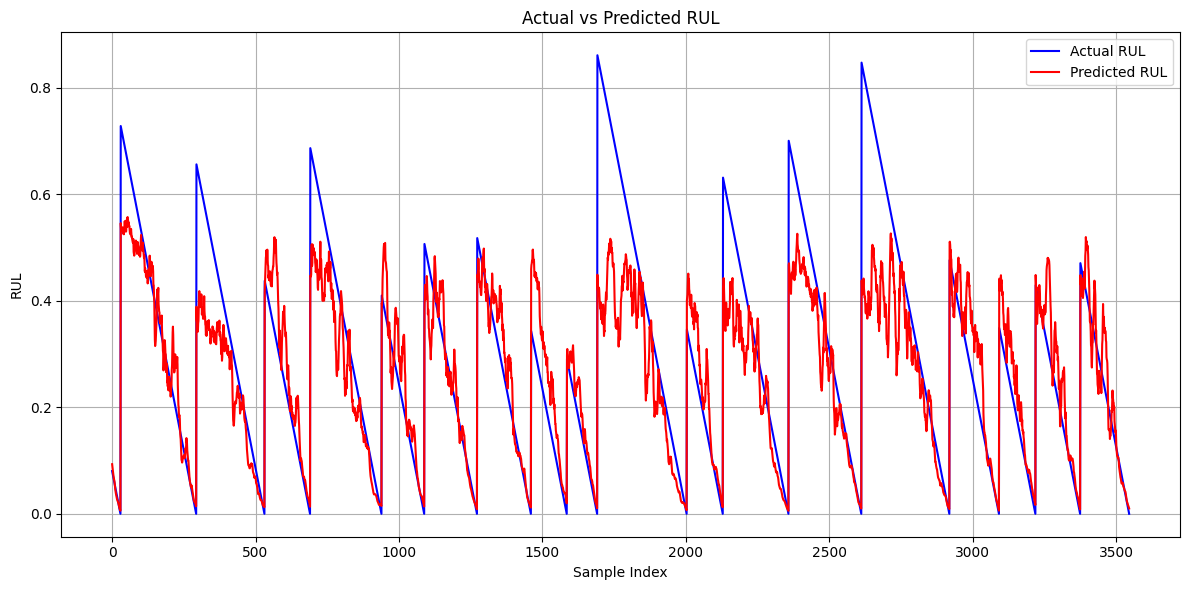

In [37]:
# Visualisasi hasil prediksi vs nilai aktual RUL
plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual RUL', color='blue')
plt.plot(y_pred, label='Predicted RUL', color='red')
plt.title('Actual vs Predicted RUL')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretasi**
- MAE = 0.07 artinya rata-rata kesalahan prediksi model hanya 0.07 unit RUL, atau bisa dikatakan prediksi sisa umur mesin hampir mendekati nilai aktual.
- RMSE = 0.11 memperkuat hal ini, karena nilai RMSE yang rendah menunjukkan bahwa prediksi tidak hanya akurat secara rata-rata, tetapi juga konsisten (tidak ada outlier besar).
- Grafik perbandingan Actual RUL dengan Predicted RUL menunjukan hasil prediksi model yang sangat baik. Predicted RUL berhasil mengikuti pola pada Actual RUL.

**Kesimpulan:**
Model LSTM yang telah dilatih dan dituning menunjukkan performa yang sangat baik, dengan MAE sebesar 0.07 dan RMSE sebesar 0.11 pada data pengujian. Hal ini menunjukkan bahwa model mampu memprediksi Remaining Useful Life (RUL) mesin secara akurat dan stabil, yang sangat bermanfaat dalam penerapan sistem predictive maintenance pada industri.